In [1]:
# =============
# CARGA DE LIBRERIAS

from astropy.io import fits
import gc
import math
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np
import os
import pickle
import random
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

In [ ]:
# =============
# CARGA DE DATASETS

# Definir la clase Dataset
class SpectraDataset(Dataset):
    def __init__(self, dataset_path):
        # Cargamos el diccionario previamente guardado (.pt)
        data = torch.load(dataset_path)
        self.flux = data["flux"]          # Tensor con forma [N, num_points]
        self.wavelength = data["wavelength"]  # Tensor con forma [N, num_points]
        self.redshift = data["redshift"]      # Tensor con forma [N]
    
    def __len__(self):
        return self.flux.shape[0]
    
    def __getitem__(self, idx):
        input_sample = torch.cat([self.flux[idx], self.wavelength[idx]], dim=0)
        target = self.redshift[idx]
        return input_sample, target


# Rutas a los archivos preprocesados
data_dir = "data"
train_dataset_path = os.path.join(data_dir, "train_dataset_1M.pt")
test_dataset_path  = os.path.join(data_dir, "test_dataset_1M.pt")

# Crear los datasets
train_dataset = SpectraDataset(train_dataset_path)
test_dataset  = SpectraDataset(test_dataset_path)

# Crear DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

In [3]:
# =============
# DEFINICIÓN Y CONFIGURACIÓN DEL MODELO

# Configurar dispositivo para GPU si está disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# Número de puntos en cada espectro
num_points = 5000 * 2  # 5000 puntos para el flujo y 5000 para la longitud de onda

# Definir el modelo MLP en PyTorch
class MLP(nn.Module):
    def __init__(self, input_dim):
        super(MLP, self).__init__()
        self.modelMLP = nn.Sequential(
            nn.Linear(input_dim, 2048),
            nn.ReLU(),
            nn.Linear(2048, 1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(p=0.5),  # Regularización con Dropout
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.modelMLP(x)

# Instanciar el modelo y moverlo a GPU si está disponible
modelMLP = MLP(num_points).to(device)
criterion = nn.L1Loss()
optimizer = optim.Adam(modelMLP.parameters(), lr=0.0001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

print("Modelo configurado correctamente.")

Usando dispositivo: cuda
Modelo configurado correctamente.


In [ ]:
# =============
# INICIALIZACIÓN DEL MODELO

num_epochs = 1
best_val_loss = float('inf')  # Para almacenar la mejor pérdida de validación

for epoch in range(num_epochs):
    modelMLP.train()
    running_loss = 0.0
    
    # Bucle de entrenamiento con barra de progreso
    for batch_X, batch_y in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Entrenamiento"):
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = modelMLP(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * batch_X.size(0)
    
    epoch_loss = running_loss / len(train_dataset)
    
    # Evaluación en el conjunto de validación
    modelMLP.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_X, batch_y in tqdm(test_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Validación"):
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = modelMLP(batch_X)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item() * batch_X.size(0)
    val_loss /= len(test_dataset)
    
    # Actualizar la tasa de aprendizaje según la pérdida de validación
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {epoch_loss:.4f}, Val Loss: {val_loss:.4f}, LR: {current_lr:.10f}", flush=True)
    
    # Guardar el checkpoint si hay mejora en la pérdida de validación
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        checkpoint = {
            'epoch': epoch + 1,
            'model_state_dict': modelMLP.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict()
        }
        torch.save(checkpoint, 'storage/modelMLP_1M_1.pth')
        print("Checkpoint guardado con éxito.")

# Evaluación final en el conjunto de prueba utilizando MAE
modelMLP.eval()
test_loss = 0.0
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        outputs = modelMLP(batch_X)
        loss = criterion(outputs, batch_y)
        test_loss += loss.item() * batch_X.size(0)
test_loss /= len(test_dataset)
print(f"Error absoluto medio en el conjunto de prueba: {test_loss:.4f}")

In [ ]:
# =============
# ENTRENAMIENTO GRUESO DEL MODELO (SE HACE ASÍ PARA PODER ENTRENARLO POCO A POCO)

# Cargar checkpoint y estados del modelo, optimizador y scheduler
checkpoint = torch.load('storage/modelMLP_1M_1.pth', map_location=device)
modelMLP.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
start_epoch = checkpoint['epoch']

# Definir el número total de epochs que deseas entrenar
num_epochs = 30
best_val_loss = float('inf')  # Para guardar el checkpoint en caso de mejora

# Continuar el entrenamiento desde el epoch donde se quedó
for epoch in range(start_epoch, num_epochs):
    modelMLP.train()
    running_loss = 0.0
    
    # Bucle de entrenamiento con barra de progreso
    for batch_X, batch_y in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Entrenamiento"):
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = modelMLP(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * batch_X.size(0)
    epoch_loss = running_loss / len(train_dataset)
    
    # Evaluación en el conjunto de validación
    modelMLP.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_X, batch_y in tqdm(test_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Validación"):
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = modelMLP(batch_X)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item() * batch_X.size(0)
    val_loss /= len(test_dataset)
    
    # Actualizar la tasa de aprendizaje según la pérdida de validación
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}, Val Loss: {val_loss:.4f}, LR: {current_lr:.10f}")
    
    # Guardar el checkpoint si hay mejora en la pérdida de validación
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        checkpoint = {
            'epoch': epoch + 1,
            'model_state_dict': modelMLP.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict()
        }
        torch.save(checkpoint, 'storage/modelMLP_1M_1.pth')
        print("Checkpoint guardado con éxito.")

# Evaluación final en el conjunto de prueba utilizando MAE
modelMLP.eval()
test_loss = 0.0
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        outputs = modelMLP(batch_X)
        loss = criterion(outputs, batch_y)
        test_loss += loss.item() * batch_X.size(0)
test_loss /= len(test_dataset)
print(f"Error absoluto medio en el conjunto de prueba: {test_loss:.4f}")

# Guardar los parámetros finales del modelo
checkpoint = {
    'epoch': num_epochs,
    'model_state_dict': modelMLP.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_state_dict': scheduler.state_dict()
}
torch.save(checkpoint, 'storage/modelMLP_1M_1.pth')

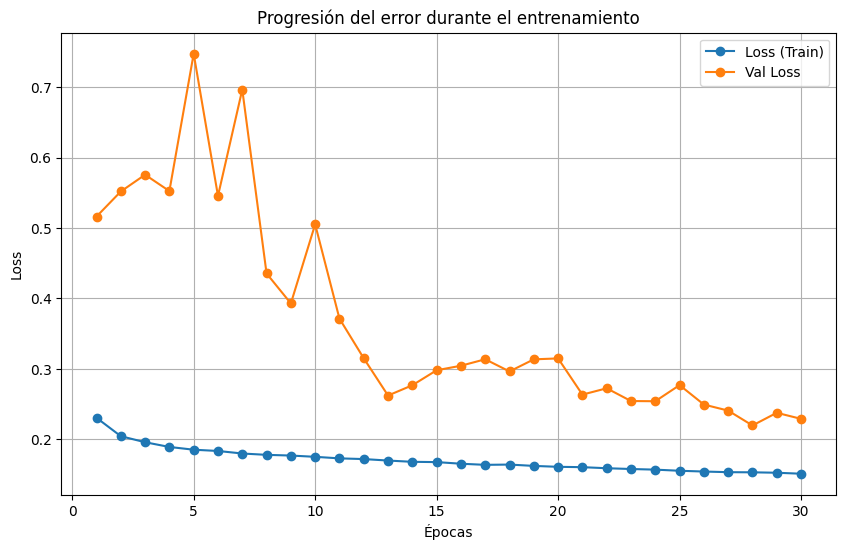

In [ ]:
import matplotlib.pyplot as plt

# Datos extraídos de los logs actualizados
epochs = list(range(1, 31))
loss = [0.2306, 0.2045, 0.1959, 0.1892, 0.1853, 0.1835, 0.1799, 0.1780, 0.1770, 0.1752,
        0.1730, 0.1720, 0.1699, 0.1681, 0.1677, 0.1654, 0.1638, 0.1642, 0.1623, 0.1610,
        0.1605, 0.1590, 0.1579, 0.1570, 0.1554, 0.1543, 0.1534, 0.1532, 0.1526, 0.1512]
val_loss = [0.5163, 0.5519, 0.5757, 0.5525, 0.7475, 0.5456, 0.6966, 0.4355, 0.3930, 0.5053,
            0.3714, 0.3151, 0.2622, 0.2768, 0.2981, 0.3045, 0.3137, 0.2964, 0.3136, 0.3149,
            0.2635, 0.2725, 0.2544, 0.2541, 0.2770, 0.2494, 0.2408, 0.2197, 0.2377, 0.2291]

# Crear la gráfica
plt.figure(figsize=(10,6))
plt.plot(epochs, loss, marker='o', label='Loss (Train)')
plt.plot(epochs, val_loss, marker='o', label='Val Loss')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.title('Progresión del error durante el entrenamiento')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# =============
# EVALUACIÓN Y REPRESENTACIÓN EN BASE A LOS DATASETS USADOS HASTA AHORA

# Cargar checkpoint y estados del modelo, optimizador y scheduler
checkpoint = torch.load('storage/modelMLP_1M_1.pth', map_location=device)
modelMLP.load_state_dict(checkpoint['model_state_dict'])

all_preds = []
all_y = []
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        preds = modelMLP(inputs).cpu().numpy()  # forma: (batch_size, 1)
        all_preds.append(preds)
        all_y.append(targets.numpy())
    for inputs, targets in train_loader:
        inputs = inputs.to(device)
        preds = modelMLP(inputs).cpu().numpy()  # forma: (batch_size, 1)
        all_preds.append(preds)
        all_y.append(targets.numpy())

# Concatenar y convertir a vectores 1D (aplicamos squeeze a ambos)
preds_all = np.concatenate(all_preds, axis=0).squeeze()
y_all = np.concatenate(all_y, axis=0).squeeze()

# Calcular la correlación lineal
corr = np.corrcoef(y_all, preds_all)[0, 1]
print(f"Correlación lineal: {corr:.4f}")

slope, intercept = np.polyfit(y_all, preds_all, 1)
print("Slope:", slope)
print("Intercept:", intercept)

Correlación lineal: 0.7036
Slope: 0.7275818594776617
Intercept: 0.1874559641501292


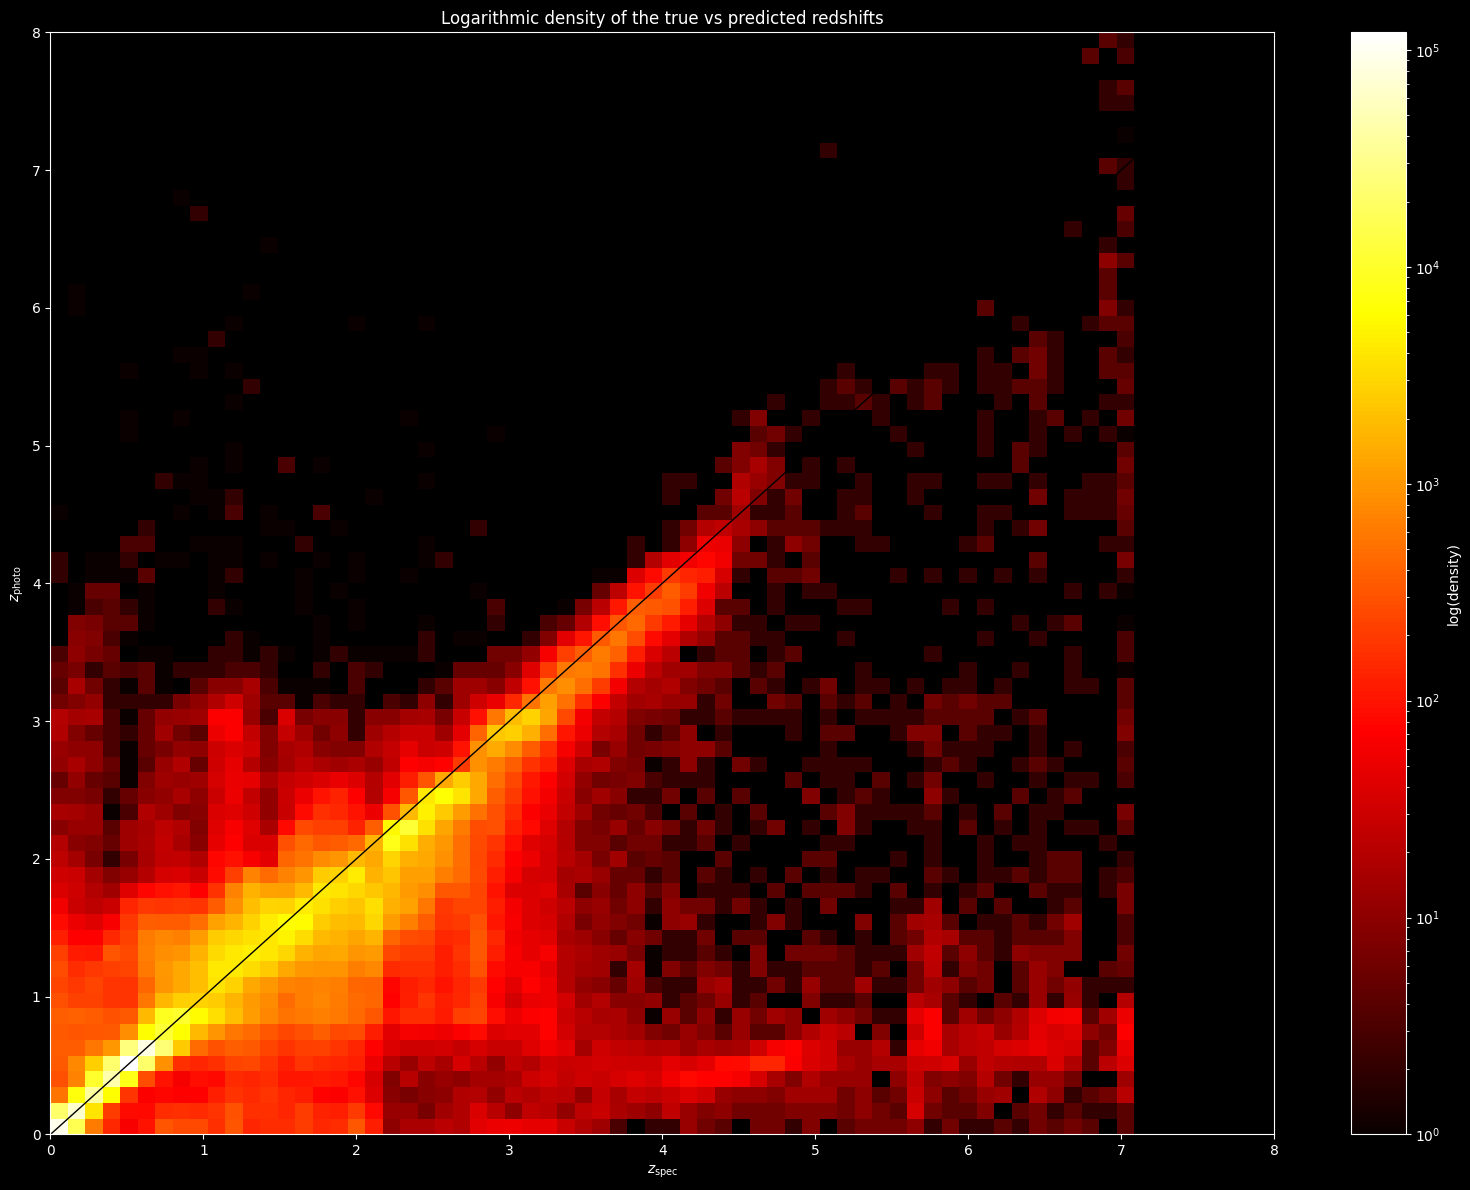

In [ ]:
# Mapa de calor de z_real frente a z_predicho éstandar
plt.style.use('dark_background')
x_min, x_max = 0, 8
y_min, y_max = 0, 8
# x_min, x_max = 0, 1
# y_min, y_max = 0, 1
# x_min, x_max = 1, 4
# y_min, y_max = 1, 4
# x_min, x_max = 4, 8
# y_min, y_max = 4, 8
plt.figure(figsize=(16, 12))

# Cálculo del histograma 2D con escala logarítmica
counts, xedges, yedges, im = plt.hist2d(
    y_all,                 # z_spec (redshift "real")
    preds_all,      # z_photo (redshift "predicho")
    bins=70,
    range=[[x_min, x_max], [y_min, y_max]],
    cmap='hot',
    norm=colors.LogNorm()  # Densidad logarítmica
)
cbar = plt.colorbar(im, label='log(density)')

plt.plot([x_min, x_max], [x_min, x_max], color='black', linewidth=1)
plt.xlabel(r'$z_{\mathrm{spec}}$')
plt.ylabel(r'$z_{\mathrm{photo}}$')
plt.title('Logarithmic density of the true vs predicted redshifts')
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.tight_layout()
plt.show()

In [ ]:
# =============
# EVALUACIÓN Y REPRESENTACIÓN EN BASE A LOS DATOS COMPLETOS DE LA SDSS

from astropy.io import fits
import gc
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np
import os
import pickle
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Liberar algunos recursos que puedan estar en uso
del train_dataset, test_dataset, train_loader, test_loader
torch.cuda.empty_cache()
gc.collect()

# Configurar dispositivo para GPU si está disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# Definir la clase del Dataset para tensores (no listas)
class SpectraDataset(Dataset):
    def __init__(self, flux_pt_path, wavelength_pt_path, redshift_pt_path):
        # Cargar los tensores previamente guardados
        self.flux = torch.load(flux_pt_path)         # Tensor de forma (num_samples, num_points)
        self.wavelength = torch.load(wavelength_pt_path)
        self.redshift = torch.load(redshift_pt_path)   # Tensor de forma (num_samples, 1) o (num_samples,)
        
    def __len__(self):
        return self.flux.shape[0]
    
    def __getitem__(self, idx):
        # Concatenar flux y wavelength en un único tensor de entrada de dimensión [num_points*2]
        input_sample = torch.cat([self.flux[idx], self.wavelength[idx]], dim=0)  # Resultado: [5000 + 5000] = [10000]
        target = self.redshift[idx]
        return input_sample, target

# Definir el modelo MLP en PyTorch
class MLP(nn.Module):
    def __init__(self, input_dim):
        super(MLP, self).__init__()
        self.modelMLP = nn.Sequential(
            nn.Linear(input_dim, 2048),
            nn.ReLU(),
            nn.Linear(2048, 1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(p=0.5),  # Regularización con Dropout
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.modelMLP(x)

# Aquí se duplica num_points para considerar la concatenación de dos canales
num_points = 5000 * 2  # Número total de puntos en cada muestra, es decir, 10,000
model_checkpoint = 'storage/modelMLP_1M_1.pth'  # Ruta del checkpoint del modelo

# Instanciar el modelo y cargar el checkpoint
modelMLP = MLP(num_points).to(device)
checkpoint = torch.load(model_checkpoint, map_location=device)
modelMLP.load_state_dict(checkpoint['model_state_dict'])
modelMLP.eval()

data_dir  = "data"
storage_dir = "storage"
batch_size = 32  # Parámetro de batch

# ============================
# Evaluación de la primera mitad (Half 1)

# Rutas para la primera mitad
flux_pt_path1       = os.path.join(data_dir, "spectra_data_complete_flux1.pt")
wavelength_pt_path1 = os.path.join(data_dir, "spectra_data_complete_wavelength1.pt")
redshift_pt_path1   = os.path.join(data_dir, "spectra_data_complete_redshift1.pt")

# Crear dataset y dataloader para la primera mitad
dataset1 = SpectraDataset(flux_pt_path1, wavelength_pt_path1, redshift_pt_path1)
dataloader1 = DataLoader(dataset1, batch_size=batch_size, shuffle=False)

predicted1 = []
real1 = []

with torch.no_grad():
    for x_batch, y_batch in dataloader1:
        x_batch = x_batch.to(device)  # x_batch tiene forma [batch_size, 10000]
        preds = modelMLP(x_batch).cpu().numpy()  # forma: (batch_size, 1)
        predicted1.append(preds)
        real1.append(y_batch.numpy())

# Concatenar los resultados de la primera mitad
predicted1 = np.concatenate(predicted1, axis=0)
real1 = np.concatenate(real1, axis=0)

# Guardar los resultados en archivos .npy
np.save(os.path.join(storage_dir, "predicted1_MLP1M_1.npy"), predicted1)
np.save(os.path.join(storage_dir, "real1_MLP1M_1.npy"), real1)

print("Evaluación de la primera mitad completada y resultados guardados.")

# Liberar memoria
del dataset1, dataloader1
torch.cuda.empty_cache()
gc.collect()

# ============================
# Evaluación de la segunda mitad (Half 2)

# Rutas para la segunda mitad
flux_pt_path2       = os.path.join(data_dir, "spectra_data_complete_flux2.pt")
wavelength_pt_path2 = os.path.join(data_dir, "spectra_data_complete_wavelength2.pt")
redshift_pt_path2   = os.path.join(data_dir, "spectra_data_complete_redshift2.pt")

# Crear dataset y dataloader para la segunda mitad
dataset2 = SpectraDataset(flux_pt_path2, wavelength_pt_path2, redshift_pt_path2)
dataloader2 = DataLoader(dataset2, batch_size=batch_size, shuffle=False)

predicted2 = []
real2 = []

with torch.no_grad():
    for x_batch, y_batch in dataloader2:
        x_batch = x_batch.to(device)
        preds = modelMLP(x_batch).cpu().numpy()
        predicted2.append(preds)
        real2.append(y_batch.numpy())

# Concatenar los resultados de la segunda mitad
predicted2 = np.concatenate(predicted2, axis=0)
real2 = np.concatenate(real2, axis=0)

# Guardar los resultados en archivos .npy
np.save(os.path.join(storage_dir, "predicted2_MLP1M_1.npy"), predicted2)
np.save(os.path.join(storage_dir, "real2_MLP1M_1.npy"), real2)

print("Evaluación de la segunda mitad completada y resultados guardados.")

# Liberar memoria
del dataset2, dataloader2
torch.cuda.empty_cache()
gc.collect()

Usando dispositivo: cuda
Evaluación de la primera mitad completada y resultados guardados.
Evaluación de la segunda mitad completada y resultados guardados.


0

Correlación lineal: 0.4771
Número de muestras evaluadas: 3372890


c:\Users\alfa\anaconda3\envs\TFGF\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


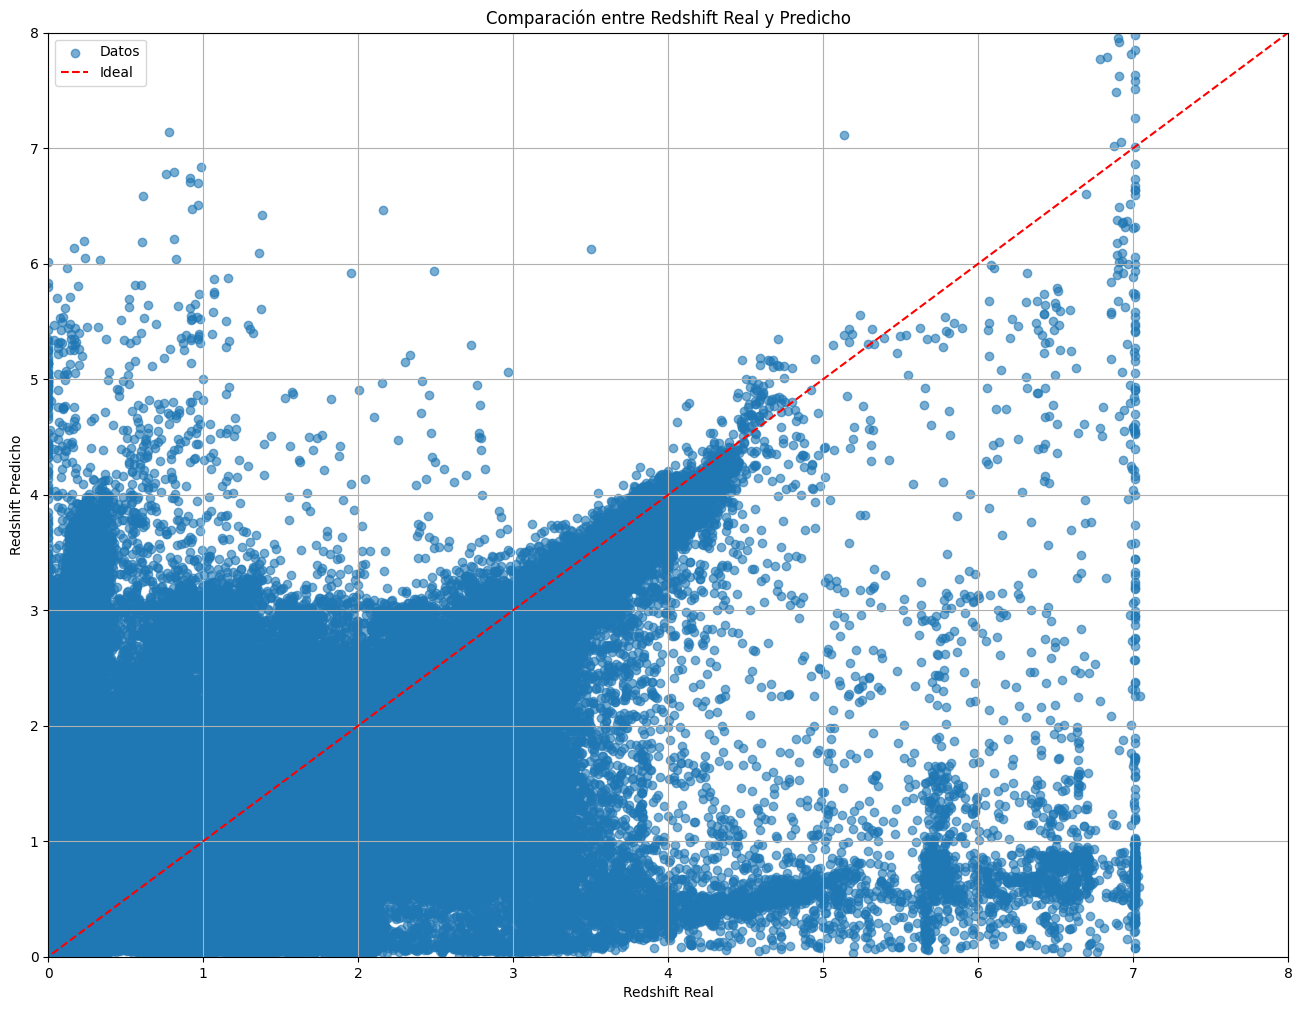

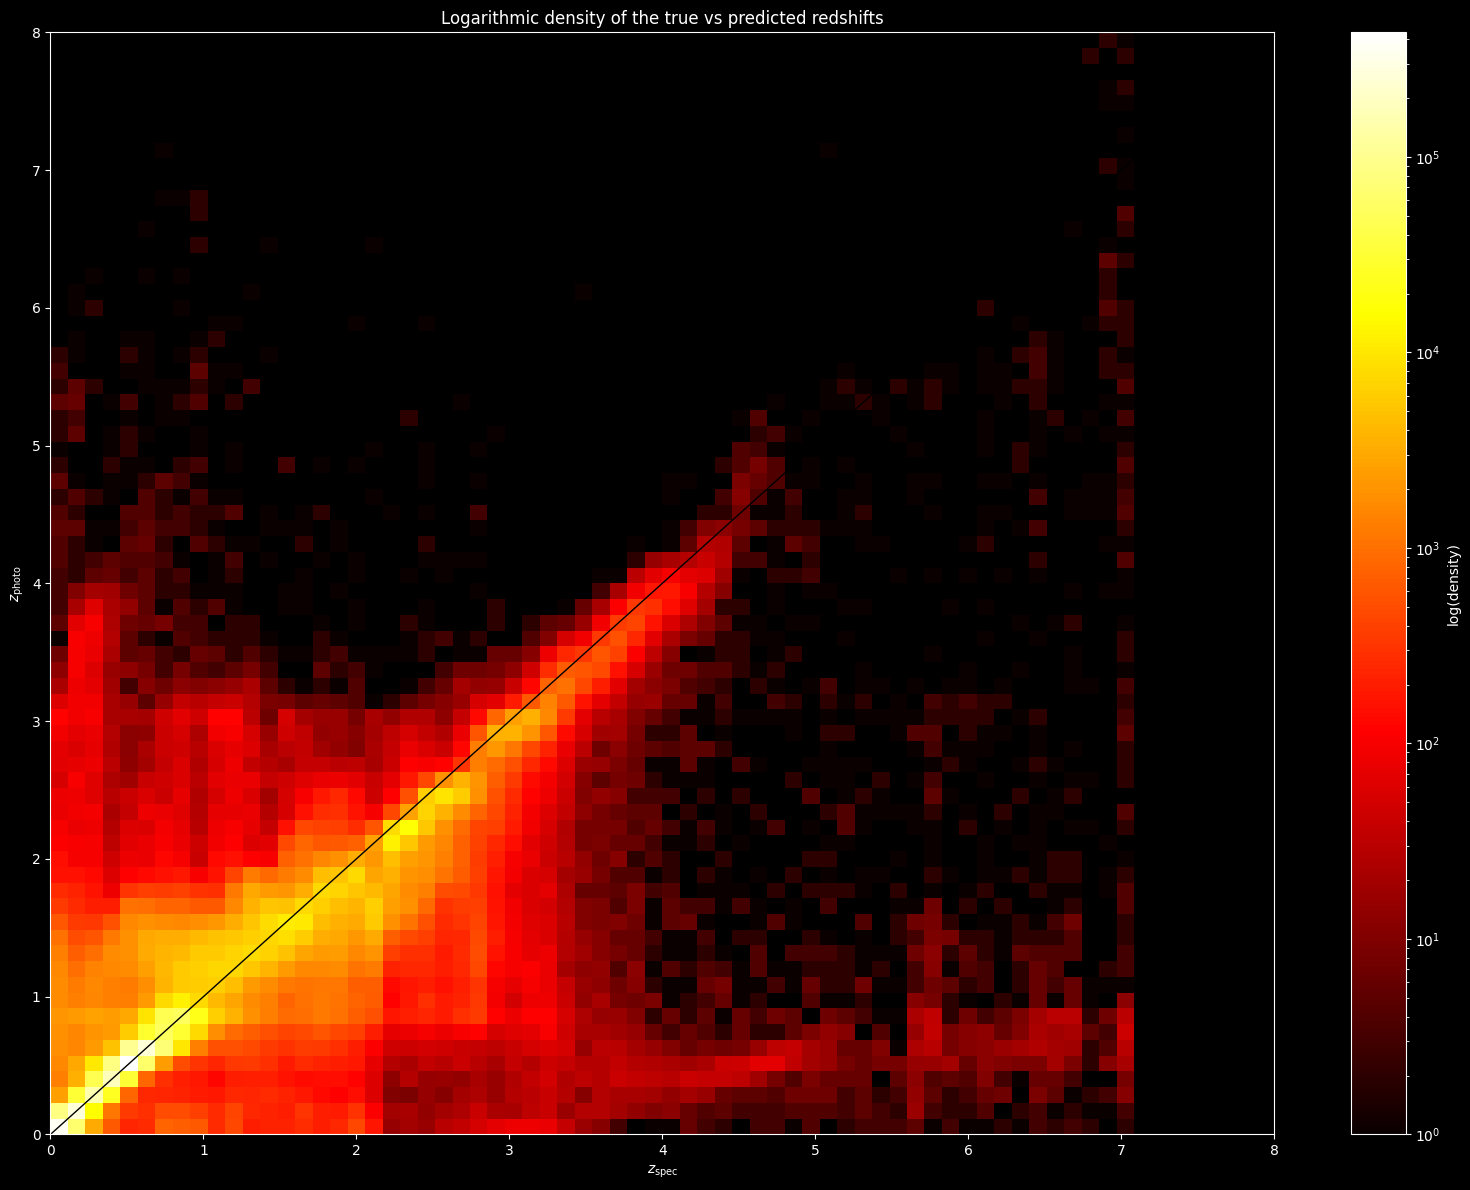

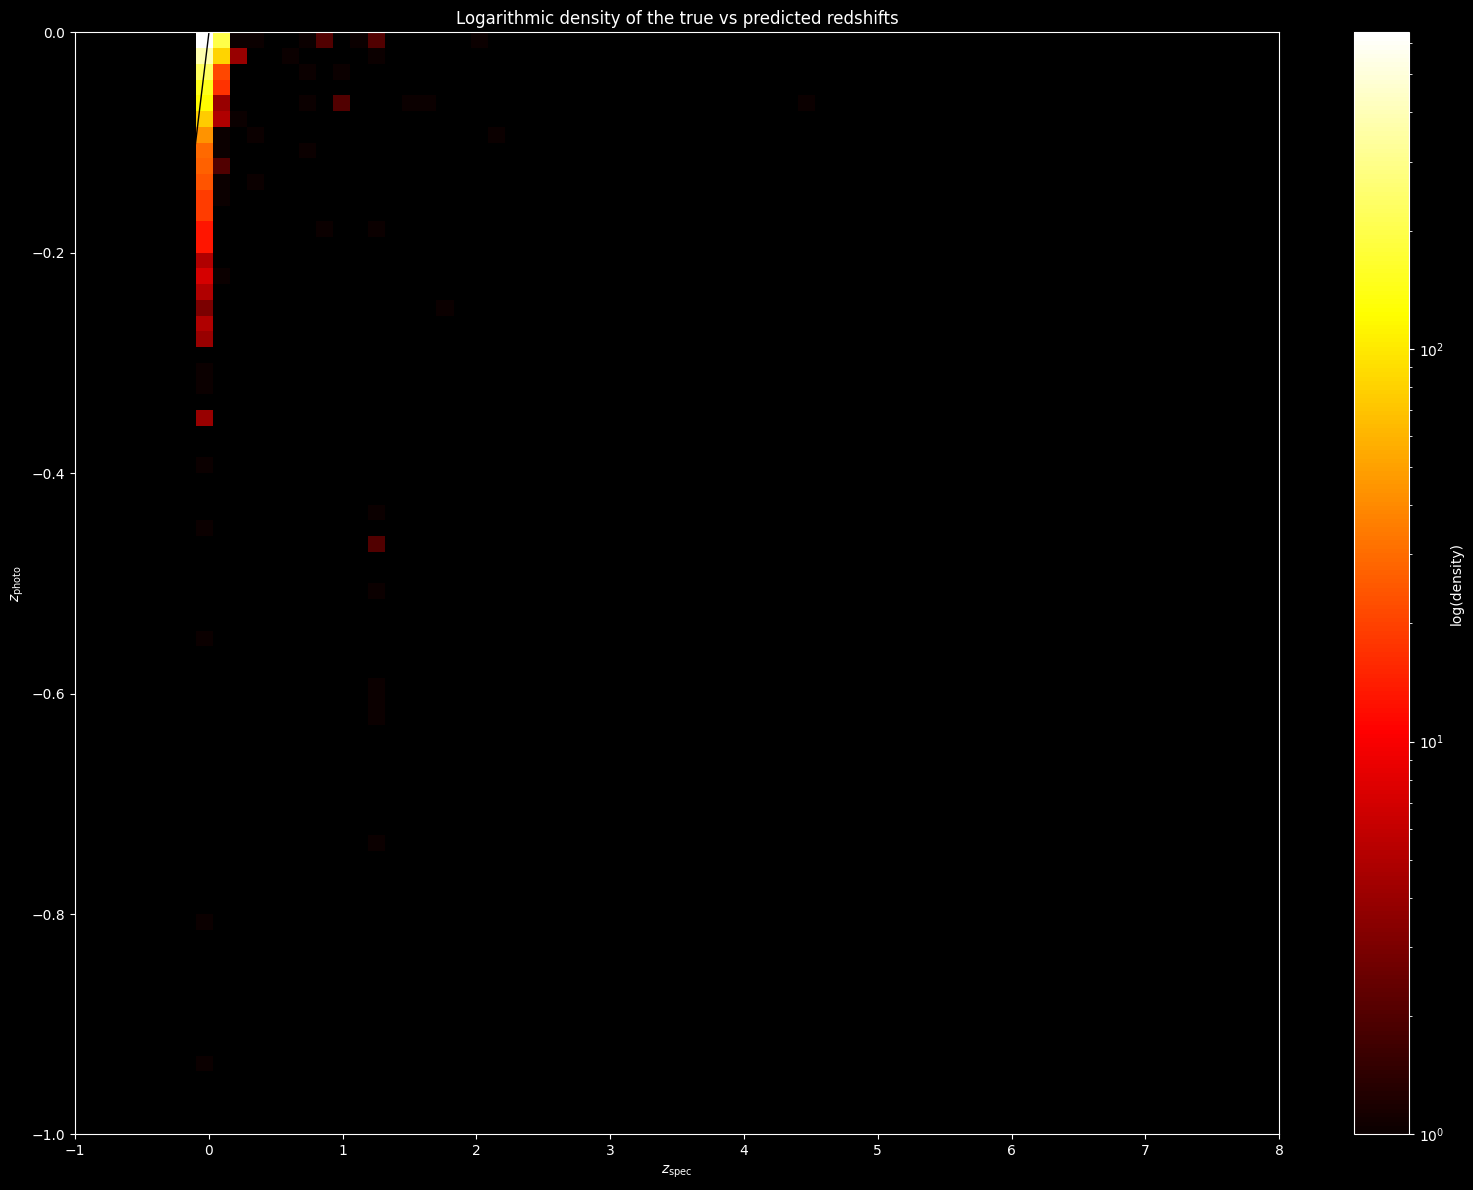

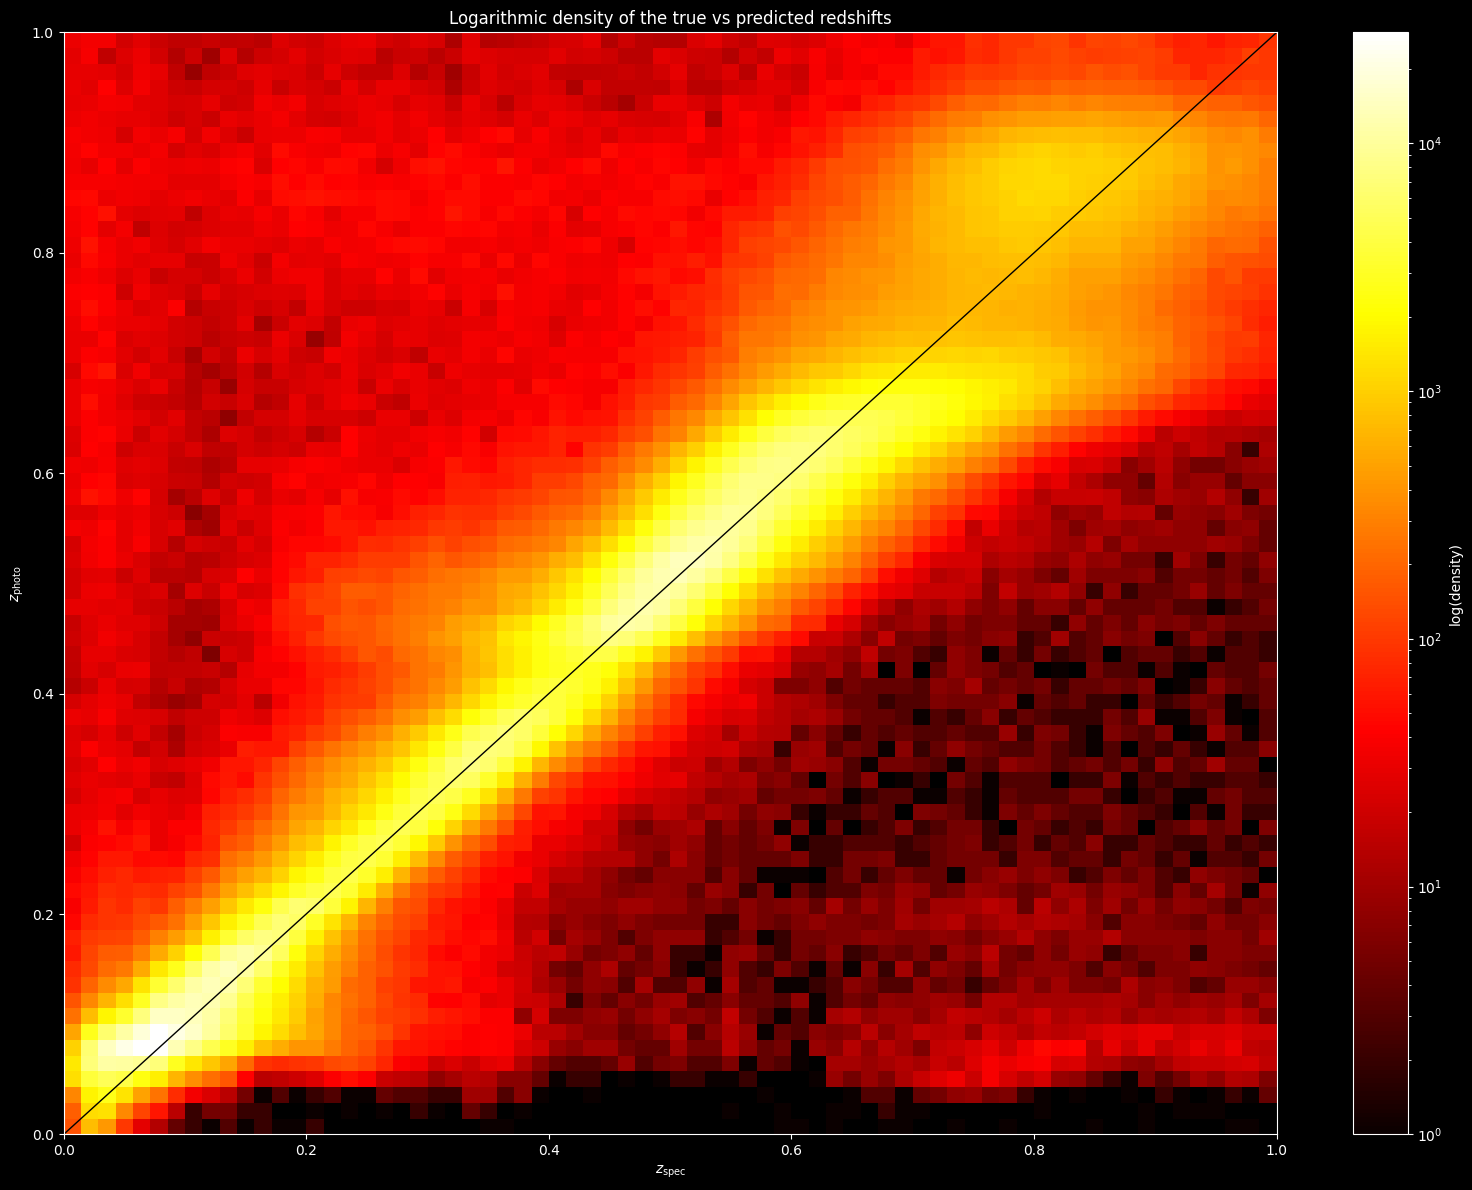

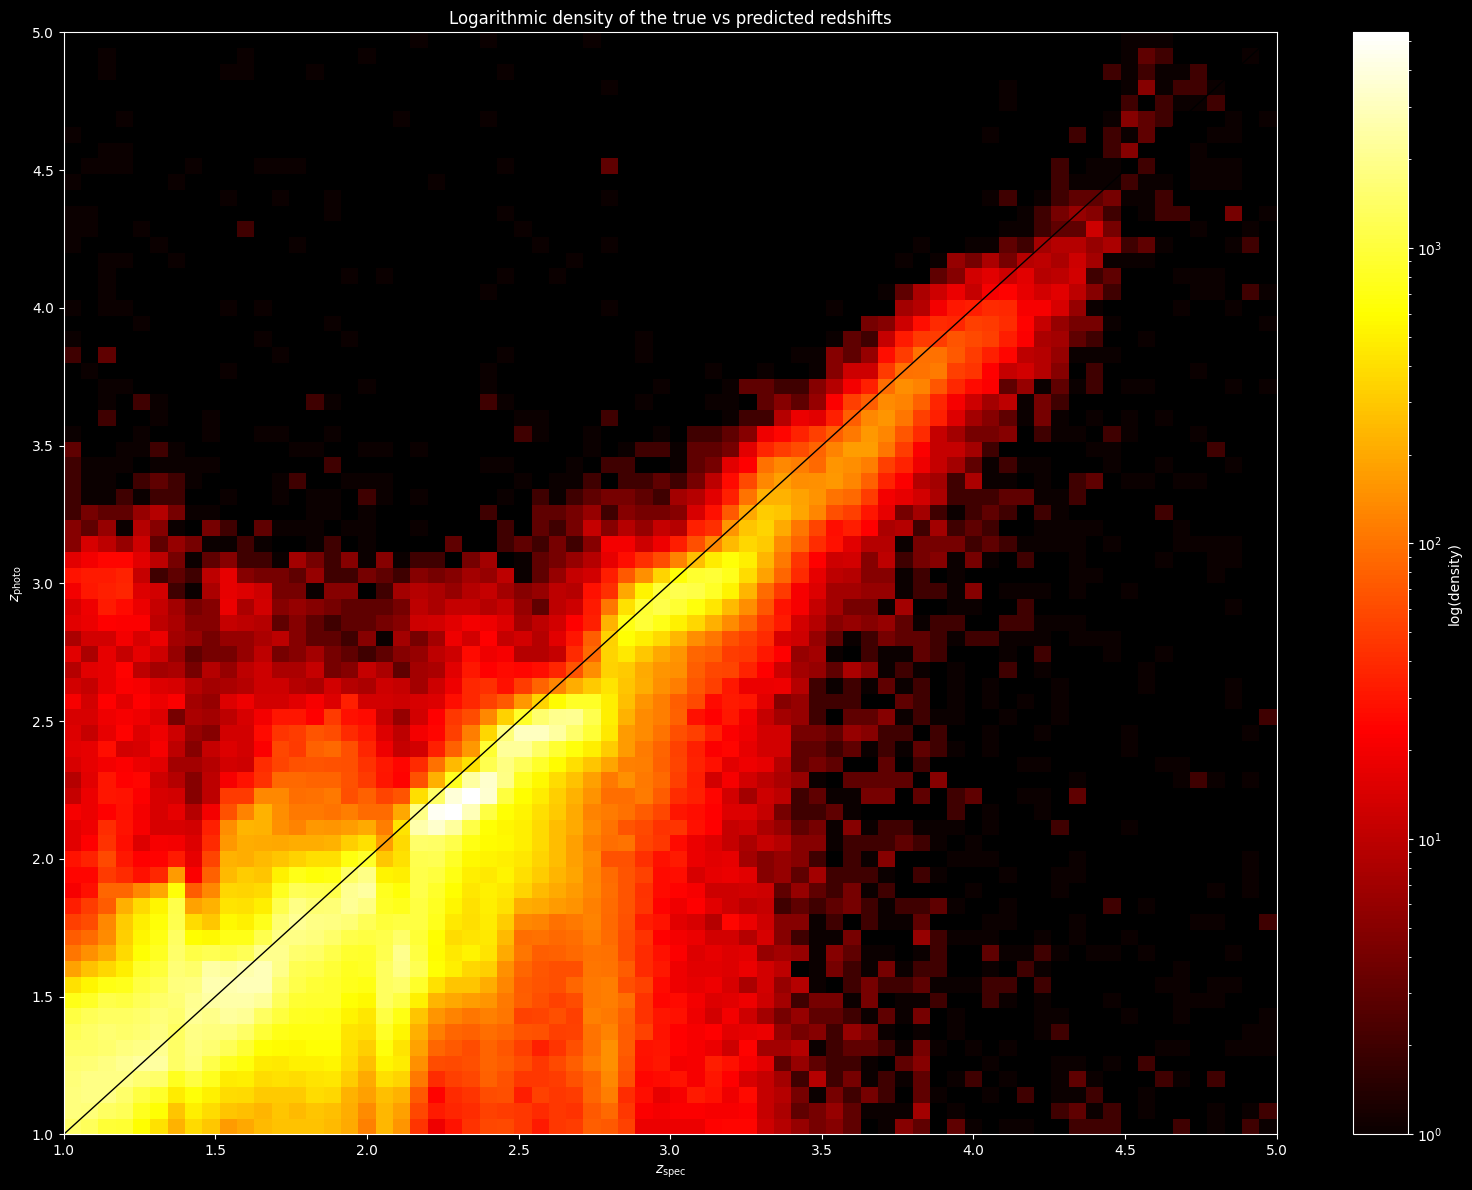

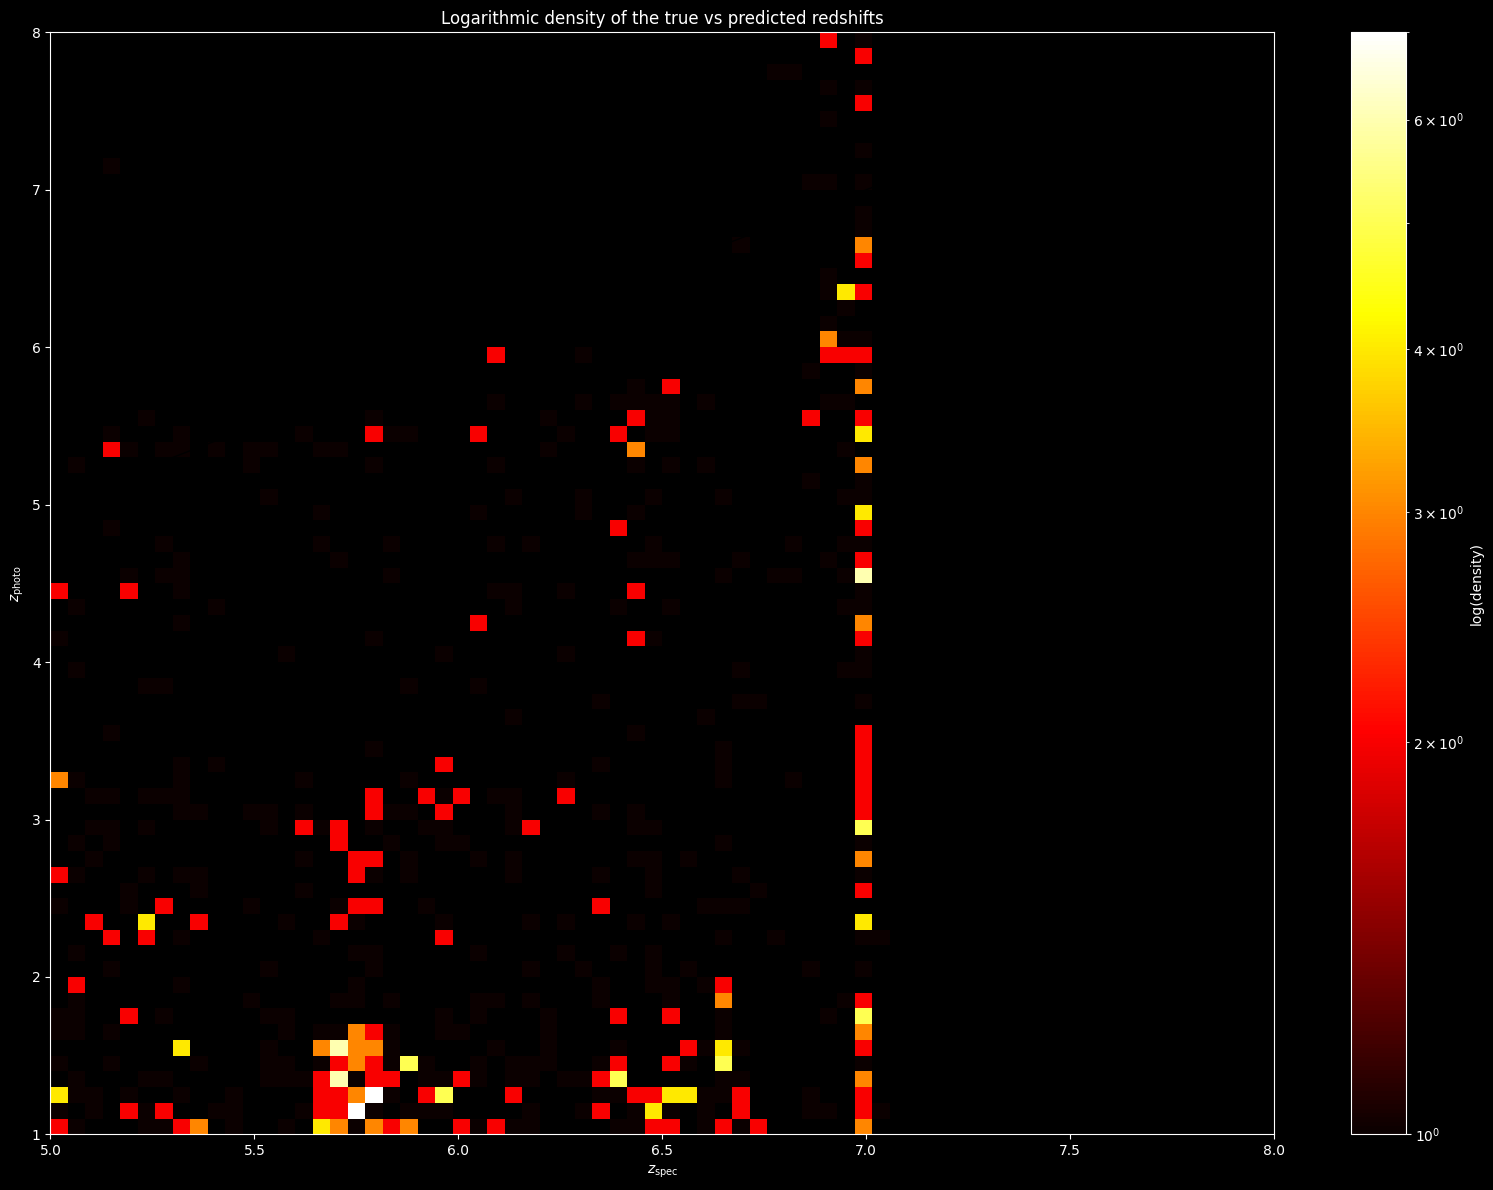

In [ ]:
# Cargar los datos guardados
predicted1 = np.load(os.path.join(storage_dir, "predicted1_MLP1M_1.npy"))
real1      = np.load(os.path.join(storage_dir, "real1_MLP1M_1.npy"))
predicted2 = np.load(os.path.join(storage_dir, "predicted2_MLP1M_1.npy"))
real2      = np.load(os.path.join(storage_dir, "real2_MLP1M_1.npy"))

# Concatenar ambos resultados
ypredicted = np.concatenate([predicted1, predicted2], axis=0)
yreal      = np.concatenate([real1, real2], axis=0)

# Asegurarse de que ambos sean vectores 1D
ypredicted = ypredicted.squeeze()     # Ahora tiene forma (N,)
yreal      = yreal.squeeze()          # Ahora tiene forma (N,)

# Calcular la correlación lineal
correlation = np.corrcoef(yreal, ypredicted)[0, 1]

print(f"Correlación lineal: {correlation:.4f}")
print(f"Número de muestras evaluadas: {len(yreal)}")

# Dispersión de puntos de z_real frente a z_predicho

plt.rcdefaults()
plt.figure(figsize=(16, 12))
plt.scatter(yreal, ypredicted, alpha=0.6, label='Datos')
plt.xlabel('Redshift Real')
plt.ylabel('Redshift Predicho')
plt.title('Comparación entre Redshift Real y Predicho')
# Añadir la línea ideal (y=x)
min_val = min(yreal.min(), ypredicted.min())
max_val = max(yreal.max(), ypredicted.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal')
plt.legend()
plt.grid(True)
plt.xlim(0, 8)
plt.ylim(0, 8)
plt.show()






# Mapa de calor de z_real frente a z_predicho éstandar

plt.style.use('dark_background')

x_min, x_max = 0, 8
y_min, y_max = 0, 8

plt.figure(figsize=(16, 12))

# Cálculo del histograma 2D con escala logarítmica
counts, xedges, yedges, im = plt.hist2d(
    yreal,                 # z_spec (redshift "real")
    ypredicted,      # z_photo (redshift "predicho")
    bins=70,
    range=[[x_min, x_max], [y_min, y_max]],
    cmap='hot',
    norm=colors.LogNorm()  # Densidad logarítmica
)

cbar = plt.colorbar(im, label='log(density)')

plt.plot([x_min, x_max], [x_min, x_max], color='black', linewidth=1)
plt.xlabel(r'$z_{\mathrm{spec}}$')
plt.ylabel(r'$z_{\mathrm{photo}}$')
plt.title('Logarithmic density of the true vs predicted redshifts')
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.tight_layout()
plt.show()






# Mapa de calor de z_real frente a z_predicho para comprobar negatividad

plt.style.use('dark_background')

x_min, x_max = -1, 8
y_min, y_max = -1, 0

plt.figure(figsize=(16, 12))

# Cálculo del histograma 2D con escala logarítmica
counts, xedges, yedges, im = plt.hist2d(
    yreal,                 # z_spec (redshift "real")
    ypredicted,      # z_photo (redshift "predicho")
    bins=70,
    range=[[x_min, x_max], [y_min, y_max]],
    cmap='hot',
    norm=colors.LogNorm()  # Densidad logarítmica
)

cbar = plt.colorbar(im, label='log(density)')

plt.plot([x_min, x_max], [x_min, x_max], color='black', linewidth=1)
plt.xlabel(r'$z_{\mathrm{spec}}$')
plt.ylabel(r'$z_{\mathrm{photo}}$')
plt.title('Logarithmic density of the true vs predicted redshifts')
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.tight_layout()
plt.show()






# Mapa de calor de z_real frente a z_predicho para comprobar rangos bajos

plt.style.use('dark_background')

x_min, x_max = 0, 1
y_min, y_max = 0, 1

plt.figure(figsize=(16, 12))

# Cálculo del histograma 2D con escala logarítmica
counts, xedges, yedges, im = plt.hist2d(
    yreal,                 # z_spec (redshift "real")
    ypredicted,      # z_photo (redshift "predicho")
    bins=70,
    range=[[x_min, x_max], [y_min, y_max]],
    cmap='hot',
    norm=colors.LogNorm()  # Densidad logarítmica
)

cbar = plt.colorbar(im, label='log(density)')

plt.plot([x_min, x_max], [x_min, x_max], color='black', linewidth=1)
plt.xlabel(r'$z_{\mathrm{spec}}$')
plt.ylabel(r'$z_{\mathrm{photo}}$')
plt.title('Logarithmic density of the true vs predicted redshifts')
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.tight_layout()
plt.show()






# Mapa de calor de z_real frente a z_predicho para comprobar rangos intermedios

plt.style.use('dark_background')

x_min, x_max = 1, 5
y_min, y_max = 1, 5

plt.figure(figsize=(16, 12))

# Cálculo del histograma 2D con escala logarítmica
counts, xedges, yedges, im = plt.hist2d(
    yreal,                 # z_spec (redshift "real")
    ypredicted,      # z_photo (redshift "predicho")
    bins=70,
    range=[[x_min, x_max], [y_min, y_max]],
    cmap='hot',
    norm=colors.LogNorm()  # Densidad logarítmica
)

cbar = plt.colorbar(im, label='log(density)')

plt.plot([x_min, x_max], [x_min, x_max], color='black', linewidth=1)
plt.xlabel(r'$z_{\mathrm{spec}}$')
plt.ylabel(r'$z_{\mathrm{photo}}$')
plt.title('Logarithmic density of the true vs predicted redshifts')
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.tight_layout()
plt.show()







# Mapa de calor de z_real frente a z_predicho para comprobar rangos altos

plt.style.use('dark_background')

x_min, x_max = 5, 8
y_min, y_max = 1, 8

plt.figure(figsize=(16, 12))

# Cálculo del histograma 2D con escala logarítmica
counts, xedges, yedges, im = plt.hist2d(
    yreal,                 # z_spec (redshift "real")
    ypredicted,      # z_photo (redshift "predicho")
    bins=70,
    range=[[x_min, x_max], [y_min, y_max]],
    cmap='hot',
    norm=colors.LogNorm()  # Densidad logarítmica
)

cbar = plt.colorbar(im, label='log(density)')

plt.plot([x_min, x_max], [x_min, x_max], color='black', linewidth=1)
plt.xlabel(r'$z_{\mathrm{spec}}$')
plt.ylabel(r'$z_{\mathrm{photo}}$')
plt.title('Logarithmic density of the true vs predicted redshifts')
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.tight_layout()
plt.show()

input_wave: [ 3566.1538  3566.564   3566.9744 ... 10273.067  10275.426  10277.795 ]
Redshift real: 0.5034735
Redshift predicho: 0.5151559114456177


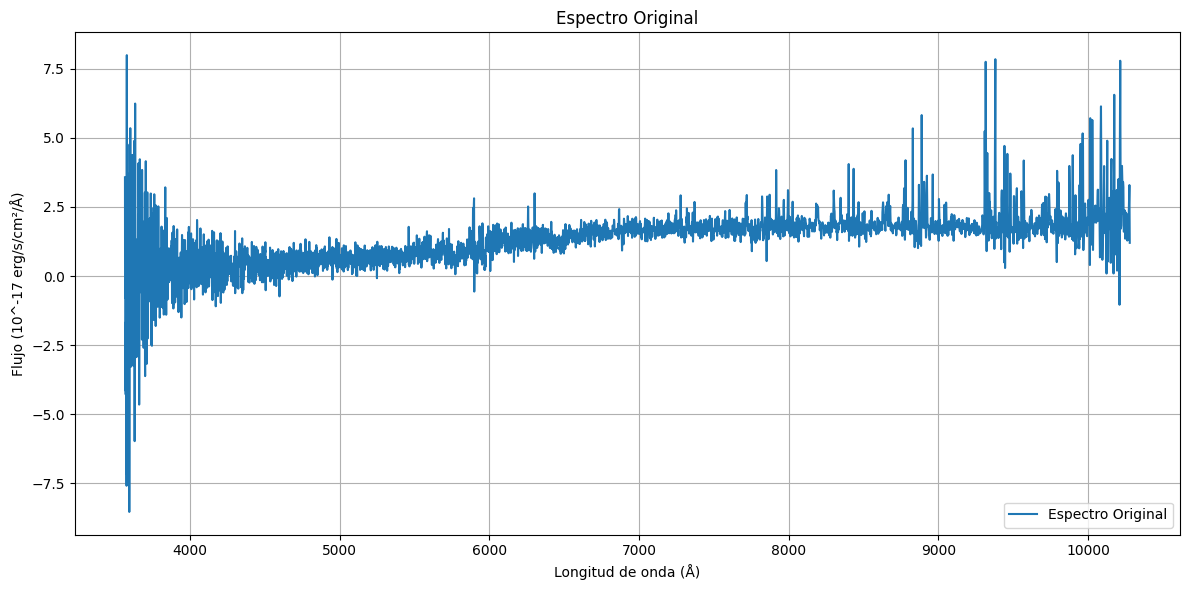

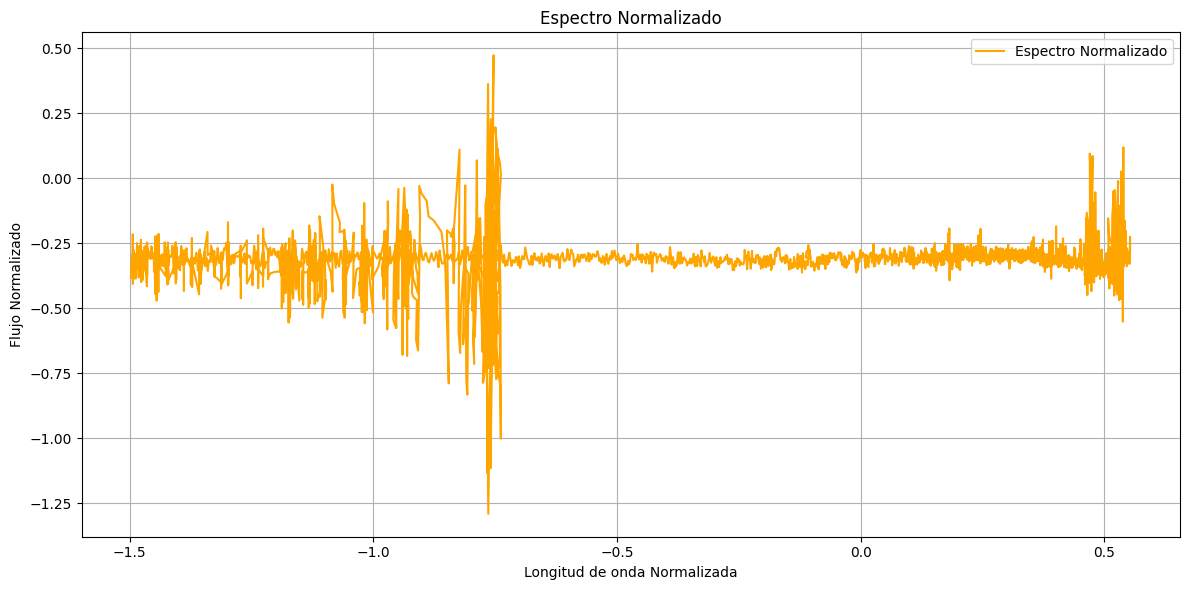

In [ ]:
import os
import random
import numpy as np
import torch
import pickle
from astropy.io import fits
import matplotlib.pyplot as plt

# Obtener la lista inicial de archivos FITS
folder_path = r'spectrums'
files = [f for f in os.listdir(folder_path) if f.endswith('.fits')]
files = random.sample(files, len(files))
file_path = os.path.join(folder_path, files[0])

# Cargar el checkpoint del modelo y los escaladores
checkpoint = torch.load('storage/modelMLP_1M_1.pth', map_location=device)
modelMLP.load_state_dict(checkpoint['model_state_dict'])
modelMLP.eval()

# Los escaladores se encuentran en un diccionario con las claves "flux_scaler" y "wavelength_scaler"
with open('extra/scaler_fitted.pkl', 'rb') as f:
    scaler_dict = pickle.load(f)
flux_scaler = scaler_dict["flux_scaler"]
wavelength_scaler = scaler_dict["wavelength_scaler"]

# Abrir el archivo FITS y extraer datos
with fits.open(file_path) as hdul:
    test_flux = hdul[1].data["flux"]
    test_loglam = hdul[1].data["loglam"]
    test_redshift = hdul[2].data["Z"][0]

# Convertir loglam a wavelength
test_wavelength = 10 ** test_loglam

def expand_points(wavelength, flux, target_count=5000):
    # Convertir a listas para facilitar las inserciones
    wl = list(wavelength)
    fl = list(flux)
    
    # Calcular las diferencias absolutas entre puntos consecutivos
    diffs = [abs(fl[i+1] - fl[i]) for i in range(len(fl)-1)]
    # Obtener los índices ordenados de mayor a menor diferencia
    sorted_indices = sorted(range(len(diffs)), key=lambda i: diffs[i], reverse=True)
    
    # Insertar nuevos puntos utilizando los índices ordenados
    while len(wl) < target_count:
        # Se recorre la lista de índices en orden descendente para evitar problemas con el reordenamiento
        for idx in sorted_indices:
            if len(wl) >= target_count:
                break
            # Calcular la interpolación lineal entre el punto idx y el siguiente
            new_wl = (wl[idx] + wl[idx+1]) / 2
            new_fl = (fl[idx] + fl[idx+1]) / 2
            wl.insert(idx+1, new_wl)
            fl.insert(idx+1, new_fl)
    
    return np.array(wl), np.array(fl)

# Hay exactamente 5000 en cada canal
test_wavelength, test_flux = expand_points(test_wavelength, test_flux, target_count=5000)

# Preprocesamiento para el modelo
# Redimensionar cada canal para que tenga forma (1, original_points)
input_flux = test_flux.reshape(1, -1)              # (1, 5000)
input_wavelength = test_wavelength.reshape(1, -1)  # (1, 5000)
print("input_wave:", test_wavelength)

# Aplicar la normalización con los escaladores correspondientes (cada uno entrenado con 5000 características)
flux_scaled = flux_scaler.transform(input_flux)                       # (1, 5000)
wavelength_scaled = wavelength_scaler.transform(input_wavelength)     # (1, 5000)

# Concatenar ambos canales a lo largo de la dimensión de características => (1, 10000)
input_scaled = np.concatenate([flux_scaled, wavelength_scaled], axis=1)

# Convertir a tensor (usando torch.from_numpy para no saturar la memoria)
input_tensor = torch.from_numpy(input_scaled).to(device).float()

# Evaluación del modelo
with torch.no_grad():
    predicted_redshift = modelMLP(input_tensor)

plt.rcdefaults()
print("Redshift real:", test_redshift)
print("Redshift predicho:", predicted_redshift.item())

# Representación de espectros
plt.figure(figsize=(12, 6))
plt.plot(test_wavelength, test_flux, label="Espectro Original")
plt.xlabel("Longitud de onda (Å)")
plt.ylabel("Flujo (10^-17 erg/s/cm²/Å)")
plt.title("Espectro Original")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(wavelength_scaled.flatten(), flux_scaled.flatten(), label="Espectro Normalizado", color="orange")
plt.xlabel("Longitud de onda Normalizada")
plt.ylabel("Flujo Normalizado")
plt.title("Espectro Normalizado")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()